# Comparison of ATC-PHD with SD-WAA in a scenario with a heterogeneous sensor network

In [ ]:
from DiffPHD import CVM, Radar, Simulator, GaussianMixture
from SDWAAPHD import Simulator as SDWAASimulator
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [42]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 8,
        "lines.linewidth": 0.8,
    }
)

In [43]:
pickle_file = "cached-data.pkl"

In [44]:
SEED = 123

## Settings

In [45]:
q = 100

gospa_c = 400
gospa_p = 2
gospa_alpha = 2

radars = [
    Radar(
        id="A",
        center=np.array([0, 0]),
        radius=1000,
        clutter_intensity_per_unit=10 / (1000)**2 / np.pi,
        model=CVM(q=q, r=2800),
        detection_probability=0.9,
    ),
    Radar(
        id="B",
        center=np.array([700, -400]),
        radius=900,
        clutter_intensity_per_unit=10 / (900)**2 / np.pi,
        model=CVM(q=q, r=2100),
        detection_probability=0.92,
    ),
    Radar(
        id="C",
        center=np.array([900, 600]),
        radius=800,
        clutter_intensity_per_unit=10 / (800)**2 / np.pi,
        model=CVM(q=q, r=2400),
        detection_probability=0.96,
    ),
    Radar(
        id="D",
        center=np.array([-900, 700]),
        radius=800,
        clutter_intensity_per_unit=10 / (800)**2 / np.pi,
        model=CVM(q=q, r=1300),
        detection_probability=0.94,
    ),
    Radar(
        id="E",
        center=np.array([-1200, -400]),
        radius=1000,
        clutter_intensity_per_unit=10 / (1000)**2 / np.pi,
        model=CVM(q=q, r=1500),
        detection_probability=0.91,
    ),
    Radar(
        id="F",
        center=np.array([-2000, 500]),
        radius=900,
        clutter_intensity_per_unit=10 / (900)**2 / np.pi,
        model=CVM(q=q, r=800),
        detection_probability=0.99,
    ),
    Radar(
        id="G",
        center=np.array([-2400, -200]),
        radius=1100,
        clutter_intensity_per_unit=10 / (1100)**2 / np.pi,
        model=CVM(q=q, r=1300),
        detection_probability=0.95,
    ),
    Radar(
        id="H",
        center=np.array([100, 1200]),
        radius=700,
        clutter_intensity_per_unit=10 / (700)**2 / np.pi,
        model=CVM(q=q, r=600),
        detection_probability=0.98,
    ),
]

graph = {
    "A": ["B", "C", "D", "E", "H"],
    "B": ["A", "C"],
    "C": ["A", "B", "H"],
    "D": ["A", "E", "F", "H"],
    "E": ["A", "D", "F", "G"],
    "F": ["D", "E", "G"],
    "G": ["E", "F"],
    "H": ["A", "C", "D"],
}

birth_intensity = GaussianMixture(
    [
        np.array([-100, 1300, 0, 0]),
        np.array([-1800, 900, 0, 0]),
        np.array([-2400, -500, 0, 0]),
        np.array([300, -400, 0, 0]),
        np.array([-600, -400, 0, 0]),
    ],
    [np.diag([10, 10, 10, 10])] * 5,
    [0.05] * 5,
)

estimate_threshold = 0.5
pruning_threshold = 0.01
merging_threshold = 3
combine_strategy = "mm"

## Network visualization

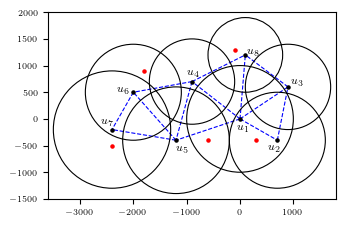

In [46]:
simulator_atcphd = Simulator(
    seed=SEED,
    radars=radars,
    graph=graph,
    birth_intensity=birth_intensity,
    model=CVM(q=q),
    estimate_threshold=estimate_threshold,
    pruning_threshold=pruning_threshold,
    merging_threshold=merging_threshold,
    combine_strategy=combine_strategy,
)

plt.figure(figsize=(3.5, 3))

labels = {
    "A" : "$u_1$",
    "B" : "$u_2$",
    "C" : "$u_3$",
    "D" : "$u_4$",
    "E" : "$u_5$",
    "F" : "$u_6$",
    "G" : "$u_7$",
    "H" : "$u_8$",
}

offests = {
    "A": (-0.5, -2),
    "B": (-1.8, -1.8),
    "C": (0.5, 0.5),
    "D": (-1, 1.25),
    "E": (0, -2),
    "F": (-3, 0),
    "G": (-2, 1),
    "H": (0.25, 0.25),
}

distinct_pairs = []
for radar in radars:
    radar_a = simulator_atcphd.radar_network.get_radar(radar.id)
    for neighbor in graph[radar.id]:
        if (neighbor, radar.id) in distinct_pairs:
            continue
        distinct_pairs.append((radar.id, neighbor))
        radar_b = simulator_atcphd.radar_network.get_radar(neighbor)
        plt.plot(
            [radar_a.center[0], radar_b.center[0]],
            [radar_a.center[1], radar_b.center[1]],
            color="blue",
            linestyle="--",
            zorder=1,
        )
    
    plt.scatter(
        [radar_a.center[0]],
        [radar_a.center[1]],
        color="k",
        s=5,
        zorder=10,
    )

if birth_intensity is not None:
    for airport in birth_intensity:
        mean = airport.means[0]
        plt.scatter(mean[0], mean[1], color="r", s=5)

for radar in radars:
    circle = plt.Circle(radar.center, radar.radius, color="k", fill=False, linewidth=0.8, zorder=10)
    plt.gca().add_artist(circle)
    plt.text(radar.center[0] + offests[radar.id][0] * 100, radar.center[1] + offests[radar.id][1] * 100, labels[radar.id])
plt.grid(False)
plt.xlim(
    simulator_atcphd.radar_network.rectangle[0, 0] - 100,
    simulator_atcphd.radar_network.rectangle[1, 0] + 100,
)
plt.ylim(
    simulator_atcphd.radar_network.rectangle[1, 1] - 100,
    simulator_atcphd.radar_network.rectangle[0, 1] + 100,
)
plt.gca().set_aspect("equal", adjustable="box")


plt.tick_params(axis="both", which="major", labelsize=6)
plt.tick_params(axis="both", which="minor", labelsize=4)

plt.tight_layout()
plt.show()

## Simulation

In [47]:
enabled = False  # enable long computation, else load from cached pickle file

runs = 2000
steps = 200

# computation enabled
if enabled:

    # initialize arrays
    gospa_total_sdwaa = np.zeros((runs, steps))
    gospa_localization_sdwaa = np.zeros((runs, steps))
    gospa_missed_sdwaa = np.zeros((runs, steps))
    gospa_false_sdwaa = np.zeros((runs, steps))
    gospa_total_atcphd = np.zeros((runs, steps))
    gospa_localization_atcphd = np.zeros((runs, steps))
    gospa_missed_atcphd = np.zeros((runs, steps))
    gospa_false_atcphd = np.zeros((runs, steps))

    # run with different seeds
    for run in range(runs):
        seed = SEED + steps*run

        # SD-WAA
        simulator_sdwaa = SDWAASimulator(
            seed=seed,
            radars=radars,
            graph=graph,
            birth_intensity=birth_intensity,
            model=CVM(q=q),
            estimate_threshold=estimate_threshold,
            pruning_threshold=pruning_threshold,
            merging_threshold=merging_threshold,
        )

        (
            gospa_total_sdwaa[run],
            gospa_localization_sdwaa[run],
            gospa_missed_sdwaa[run],
            gospa_false_sdwaa[run],
        ) = simulator_sdwaa.simulate(
            steps, 
            wait_for_birth=True, 
            animate=False, 
            calculate_gospa=True, 
            gospa_c=gospa_c, 
            gospa_alpha=gospa_alpha, 
            gospa_p=gospa_p 
        )

        # ATC-PHD
        simulator_atcphd = Simulator(
            seed=seed,
            radars=radars,
            graph=graph,
            birth_intensity=birth_intensity,
            model=CVM(q=q),
            estimate_threshold=estimate_threshold,
            pruning_threshold=pruning_threshold,
            merging_threshold=merging_threshold,
            combine_strategy=combine_strategy,
        )

        (
            gospa_total_atcphd[run],
            gospa_localization_atcphd[run],
            gospa_missed_atcphd[run],
            gospa_false_atcphd[run],
        ) = simulator_atcphd.simulate(
            steps, 
            wait_for_birth=True, 
            animate=False, 
            calculate_gospa=True, 
            gospa_c=gospa_c, 
            gospa_alpha=gospa_alpha, 
            gospa_p=gospa_p 
        )

    # calculate means
    gospa_total_sdwaa_mean = np.mean(gospa_total_sdwaa, axis=0)
    gospa_localization_sdwaa_mean = np.mean(gospa_localization_sdwaa, axis=0)
    gospa_missed_sdwaa_mean = np.mean(gospa_missed_sdwaa, axis=0)
    gospa_false_sdwaa_mean = np.mean(gospa_false_sdwaa, axis=0)
    gospa_total_atcphd_mean = np.mean(gospa_total_atcphd, axis=0)
    gospa_localization_atcphd_mean = np.mean(gospa_localization_atcphd, axis=0)
    gospa_missed_atcphd_mean = np.mean(gospa_missed_atcphd, axis=0)
    gospa_false_atcphd_mean = np.mean(gospa_false_atcphd, axis=0)

    # save to pickle
    with open(pickle_file, "wb") as f:
        pickle.dump(
            (
                gospa_total_sdwaa_mean,
                gospa_localization_sdwaa_mean,
                gospa_missed_sdwaa_mean,
                gospa_false_sdwaa_mean,
                gospa_total_atcphd_mean,
                gospa_localization_atcphd_mean,
                gospa_missed_atcphd_mean,
                gospa_false_atcphd_mean,
            ),
            f,
        )

# computation disabled: load results from pickle
else:
    with open(pickle_file, "rb") as f:
        (
            gospa_total_sdwaa_mean,
            gospa_localization_sdwaa_mean,
            gospa_missed_sdwaa_mean,
            gospa_false_sdwaa_mean,
            gospa_total_atcphd_mean,
            gospa_localization_atcphd_mean,
            gospa_missed_atcphd_mean,
            gospa_false_atcphd_mean,
        ) = pickle.load(f)

## Results

### Total GOSPA

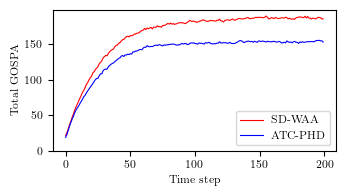

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2))

ax.plot(gospa_total_sdwaa_mean, label="SD-WAA", color="red")
ax.plot(gospa_total_atcphd_mean, label="ATC-PHD", color="blue")

ax.set_ylim(bottom=0)

ax.set_xlabel("Time step")
ax.set_ylabel("Total GOSPA")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### GOSPA components

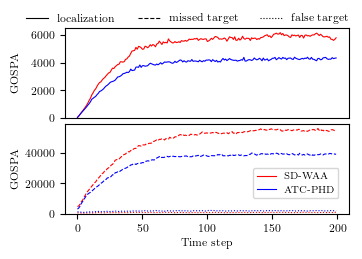

In [49]:
fig, axs = plt.subplots(2, 1, figsize=(3.5, 2.4))

(sdwaa,) = axs[0].plot(gospa_localization_sdwaa_mean, label="SD-WAA", color="red")
(atcphd,) = axs[0].plot(gospa_localization_atcphd_mean, label="ATC-PHD", color="blue")
axs[1].plot(
    gospa_missed_sdwaa_mean,
    color="red",
    linestyle="--",
)
axs[1].plot(
    gospa_missed_atcphd_mean,
    color="blue",
    linestyle="--",
)
axs[1].plot(
    gospa_false_sdwaa_mean,
    color="red",
    linestyle=":",
)
axs[1].plot(
    gospa_false_atcphd_mean,
    color="blue",
    linestyle=":",
)

solid_line = mlines.Line2D([], [], color="black", linestyle="-", label="localization")
dashed_line = mlines.Line2D(
    [], [], color="black", linestyle="--", label="missed target"
)
dotted_line = mlines.Line2D([], [], color="black", linestyle=":", label="false target")

axs[0].set_xticks([])

axs[0].set_ylabel("GOSPA")
axs[0].set_ylim(bottom=0)

axs[0].legend(
    handles=[solid_line, dashed_line, dotted_line],
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.43, 1.27),
    frameon=False,
)

axs[1].set_xlabel("Time step")
axs[1].set_ylabel("GOSPA")
axs[1].set_ylim(bottom=0)

legend2 = axs[1].legend(handles=[sdwaa, atcphd], loc="lower right", bbox_to_anchor=(0.98, 0.12), fontsize=7)

plt.subplots_adjust(hspace=0, wspace=0)

fig.align_ylabels(axs)

plt.tight_layout(
    pad=0.0, rect=[0, 0, 1, 1]
)

plt.show()

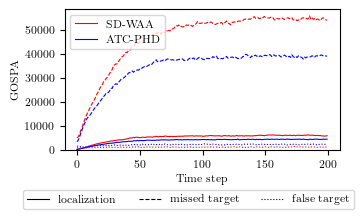

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.2))

sdwaa, = ax.plot(
    gospa_localization_sdwaa_mean, label="SD-WAA", color="red"
)
atcphd, = ax.plot(
    gospa_localization_atcphd_mean, label="ATC-PHD", color="blue"
)
ax.plot(
    gospa_missed_sdwaa_mean,
    color="red",
    linestyle="--",
)
ax.plot(
    gospa_missed_atcphd_mean,
    color="blue",
    linestyle="--",
)
ax.plot(
    gospa_false_sdwaa_mean,
    color="red",
    linestyle=":",
)
ax.plot(
    gospa_false_atcphd_mean,
    color="blue",
    linestyle=":",
)

solid_line = mlines.Line2D([], [], color="black", linestyle="-", label="localization")
dashed_line = mlines.Line2D([], [], color="black", linestyle="--", label="missed target")
dotted_line = mlines.Line2D([], [], color="black", linestyle=":", label="false target")

ax.set_xlabel("Time step")
ax.set_ylabel("GOSPA")
ax.set_ylim(bottom=0)

legend1 = ax.legend(handles=[sdwaa, atcphd], loc="upper left")
ax.add_artist(legend1)
ax.legend(handles=[solid_line, dashed_line, dotted_line], loc="upper center", ncol=3, bbox_to_anchor=(0.45, -0.25))  #

plt.tight_layout(rect=[-0.01, -0.05, 1.047, 1])
plt.show()

### Localization GOSPA

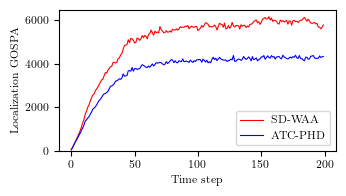

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2))

ax.plot(gospa_localization_sdwaa_mean, label="SD-WAA", color="red")
ax.plot(gospa_localization_atcphd_mean, label="ATC-PHD", color="blue")

ax.set_ylim(bottom=0)

ax.set_xlabel("Time step")
ax.set_ylabel("Localization GOSPA")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### False target GOSPA

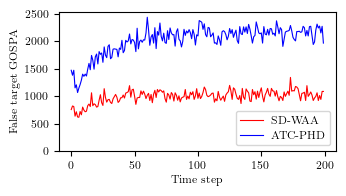

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2))

ax.plot(gospa_false_sdwaa_mean, label="SD-WAA", color="red")
ax.plot(gospa_false_atcphd_mean, label="ATC-PHD", color="blue")

ax.set_ylim(bottom=0)

ax.set_xlabel("Time step")
ax.set_ylabel("False target GOSPA")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Missed target GOSPA

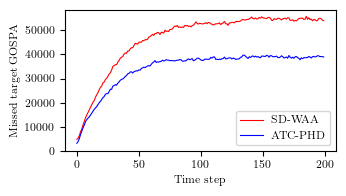

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2))

ax.plot(gospa_missed_sdwaa_mean, label="SD-WAA", color="red")
ax.plot(gospa_missed_atcphd_mean, label="ATC-PHD", color="blue")

ax.set_ylim(bottom=0)

ax.set_xlabel("Time step")
ax.set_ylabel("Missed target GOSPA")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()